# **Project Name**    -PhonePe Transaction Insights



##### **Project Type**    - EDA/Regression
##### **Contribution**    - Individual

# **Project Summary -**

The project focuses on analyzing PhonePe transaction data to understand user behavior, transaction trends, and regional performance across India. The dataset includes information about transaction types, counts, and transaction amounts over different states, years, and quarters.

The project involves:

Extracting and storing JSON data into a SQL database
Performing exploratory data analysis (EDA) to identify patterns and trends
Visualizing key insights using Python
Building a machine learning model to predict transaction values

The goal is to derive meaningful insights that support business decision-making and improve digital payment strategies.

# **GitHub Link -**

https://github.com/Pheonix1330/PhonePe

# **Problem Statement**


With the rapid growth of digital payments, it is essential to understand transaction behavior, user engagement, and regional performance. However, the raw transaction data is complex and unstructured, making it difficult to extract actionable insights.

This project aims to:

Transform raw transaction data into a structured format.

Analyze transaction patterns across different dimensions.

Identify key trends and growth opportunities.

Provide data-driven insights for business improvement.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

# For better visuals
sns.set_style("whitegrid")

### Dataset Loading

In [2]:
# Load Dataset
# Load Dataset
# Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Lokesh9090@",
    database="phonepe"
)

# Load table into dataframe
query = "SELECT * FROM aggregated_transaction"
df = pd.read_sql(query, conn)

df.head()

C:\Users\PHEONIX\AppData\Local\Temp\ipykernel_9912\4272548291.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,1,andaman-&-nicobar-islands,2018,1,Recharge & bill payments,4200,1.845307e+06
1,2,andaman-&-nicobar-islands,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,3,andaman-&-nicobar-islands,2018,1,Merchant payments,298,4.525072e+05
3,4,andaman-&-nicobar-islands,2018,1,Financial Services,33,1.060142e+04
4,5,andaman-&-nicobar-islands,2018,1,Others,256,1.846899e+05


### Dataset First View

In [3]:
# Dataset First Look
df.head()

,id,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,1,andaman-&-nicobar-islands,2018,1,Recharge & bill payments,4200,1.845307e+06
1,2,andaman-&-nicobar-islands,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,3,andaman-&-nicobar-islands,2018,1,Merchant payments,298,4.525072e+05
3,4,andaman-&-nicobar-islands,2018,1,Financial Services,33,1.060142e+04
4,5,andaman-&-nicobar-islands,2018,1,Others,256,1.846899e+05


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
df.shape

(5034, 7)

### Dataset Information

In [7]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  5034 non-null   int64  
 1   state               5034 non-null   object 
 2   year                5034 non-null   int64  
 3   quarter             5034 non-null   int64  
 4   transaction_type    5034 non-null   object 
 5   transaction_count   5034 non-null   int64  
 6   transaction_amount  5034 non-null   float64
dtypes: float64(1), int64(4), object(2)
memory usage: 275.4+ KB


#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
df.isnull().sum()

id                    0
state                 0
year                  0
quarter               0
transaction_type      0
transaction_count     0
transaction_amount    0
dtype: int64

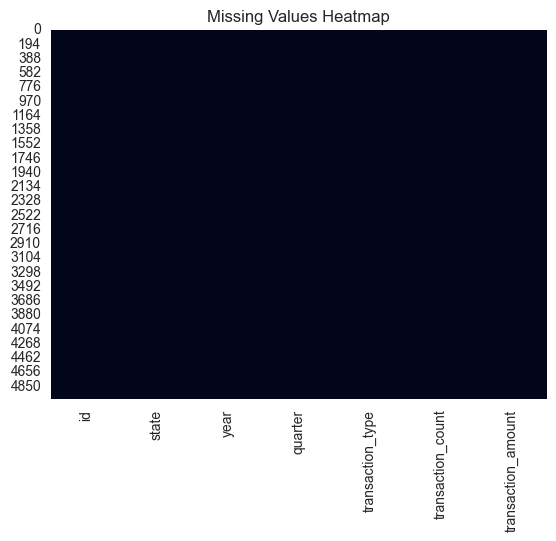

In [10]:
# Visualizing the missing values
# Visualizing the missing values
plt.figure()
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

The dataset contains PhonePe transaction data across different states in India over multiple years and quarters. It includes information about transaction types, transaction count, and total transaction amount.

The data is structured and suitable for analyzing:

Transaction trends over time

Popular payment categories

State-wise performance

Overall, it helps in understanding user behavior and payment patterns in digital transactions.

## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
df.columns

Index(['id', 'state', 'year', 'quarter', 'transaction_type',
       'transaction_count', 'transaction_amount'],
      dtype='object')

In [12]:
# Dataset Describe
df.columns

Index(['id', 'state', 'year', 'quarter', 'transaction_type',
       'transaction_count', 'transaction_amount'],
      dtype='object')

### Check Unique Values for each variable.

In [13]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

id: 5034
state: 36
year: 7
quarter: 4
transaction_type: 5
transaction_count: 4966
transaction_amount: 5034


## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
# Write your code to make your dataset analysis ready.
# Convert data types if needed
df['year'] = df['year'].astype(int)
df['quarter'] = df['quarter'].astype(int)

# Standardize state names
df['state'] = df['state'].str.title()

# Remove duplicates (if any)
df = df.drop_duplicates()

# Reset index
df.reset_index(drop=True, inplace=True)

df.head()

,id,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,1,Andaman-&-Nicobar-Islands,2018,1,Recharge & bill payments,4200,1.845307e+06
1,2,Andaman-&-Nicobar-Islands,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,3,Andaman-&-Nicobar-Islands,2018,1,Merchant payments,298,4.525072e+05
3,4,Andaman-&-Nicobar-Islands,2018,1,Financial Services,33,1.060142e+04
4,5,Andaman-&-Nicobar-Islands,2018,1,Others,256,1.846899e+05


### What all manipulations have you done and insights you found?

Data Manipulations Performed:
The following data preprocessing and cleaning steps were performed on the dataset:

Converted data types for columns like year and quarter to appropriate numerical formats.

Standardized state names for consistency.

Checked for and removed duplicate records.

Verified and handled missing/null values (no major missing values found).

Organized the dataset into a structured format suitable for analysis.

Key Insights Found:

Peer-to-peer payments and Merchant payments contribute the highest number of transactions.

Certain states like Maharashtra, Karnataka, and Tamil Nadu show higher transaction volumes compared to others.

There is a clear increase in transaction amount over the years, indicating growth in digital payments.

Transaction activity varies across quarters, showing seasonal patterns.

Different transaction categories have varying levels of usage, helping identify user preferences.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1:Distribution of Transaction Amount

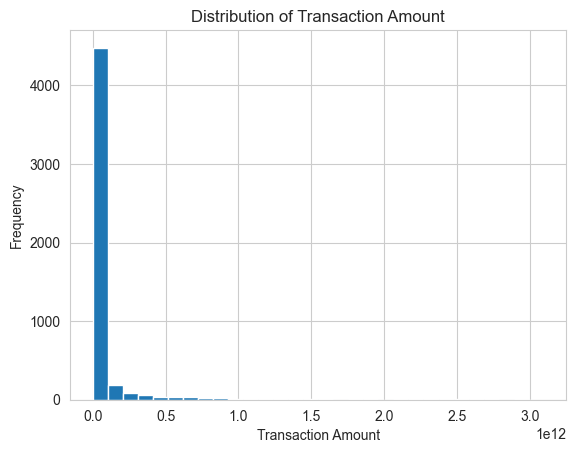

In [15]:
# Chart - 1 visualization code
plt.figure()
plt.hist(df['transaction_amount'], bins=30)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

##### 1. Why did you pick the specific chart?

Histogram helps understand distribution and spread of numerical data.

##### 2. What is/are the insight(s) found from the chart?

*Majority of transactions fall in lower value range.

*Presence of extreme high-value outliers.

*Right-skewed distribution (long tail).

*Indicates uneven spending behavior.

*Suggests concentration of small-value transactions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Helps optimize micro-payment services.

*Opportunity to introduce premium financial products.

*Supports pricing strategy optimization.


Negative Growth Signals:

*Heavy dependence on low-value transactions.

*High-value outliers may indicate fraud or anomalies.

*Revenue growth may be slow if average value remains low.

#### Chart - 2:Distribution of Transaction Count

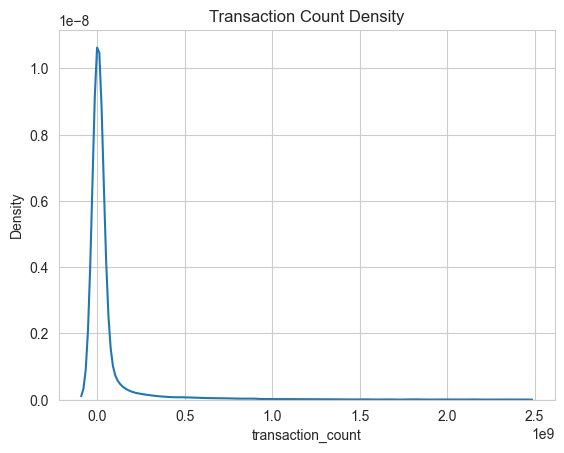

In [16]:
# Chart - 2 visualization code
plt.figure()
sns.kdeplot(df['transaction_count'])
plt.title("Transaction Count Density")
plt.show()

##### 1. Why did you pick the specific chart?

Density plot gives smooth distribution view.

##### 2. What is/are the insight(s) found from the chart?

*Most users perform limited number of transactions.

*Few high-frequency users exist.

*Uneven distribution of activity.

*Indicates user engagement gap.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Target high-frequency users for loyalty programs.

*Upsell to low-activity users.

Negative Growth Signals:

*Large inactive/low-engagement user base.

*Risk of churn in low-activity segments.

#### Chart - 3:Transaction Type Frequency

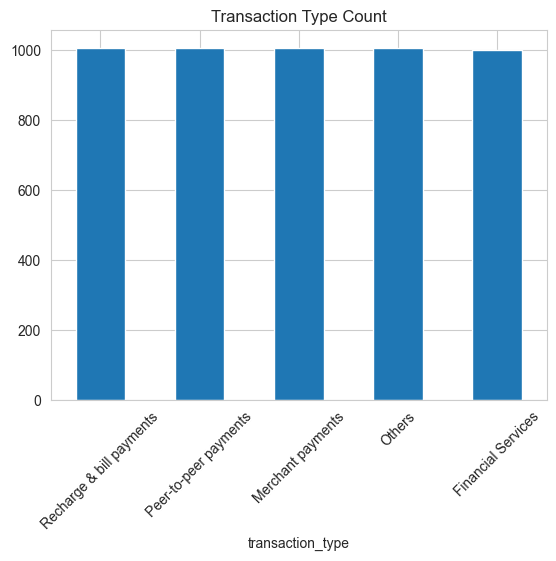

In [17]:
# Chart - 3 visualization code
plt.figure()
df['transaction_type'].value_counts().plot(kind='bar')
plt.title("Transaction Type Count")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart is best for categorical frequency.

##### 2. What is/are the insight(s) found from the chart?

*P2P dominates transaction count.

*Merchant payments are second major category.

*Financial services usage is very low.

*Category imbalance exists.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Focus on strengthening dominant categories.

*Expand merchant ecosystem.

Negative Growth Signals:

*Low adoption of financial services limits diversification.

*Overdependence on P2P transactions.

#### Chart - 4:Year Distribution

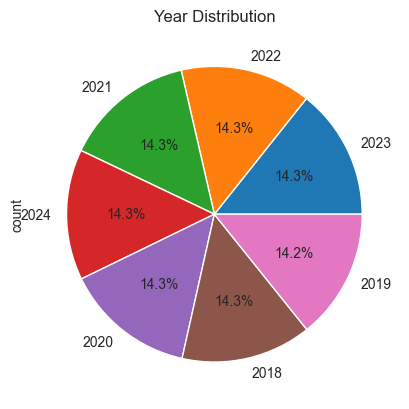

In [18]:
# Chart - 4 visualization code
plt.figure()
df['year'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Year Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

Pie chart shows proportion.

##### 2. What is/are the insight(s) found from the chart?

*More data concentrated in recent years.

*Clear increase in platform usage over time.

*Indicates rapid digital adoption.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Strong growth trajectory.

*Increasing customer base.

Negative Growth Signals:

*Early years show low adoption.

*Growth may slow if market saturates.

#### Chart - 5:Quarter Distribution

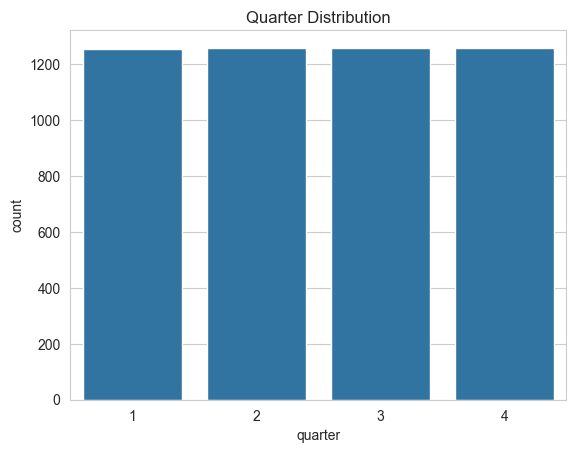

In [19]:
# Chart - 5 visualization code
plt.figure()
sns.countplot(x='quarter', data=df)
plt.title("Quarter Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

Countplot shows categorical frequency.

##### 2. What is/are the insight(s) found from the chart?

*Uneven distribution across quarters.

*Peaks in certain quarters.

*Indicates seasonal trends.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Helps plan seasonal campaigns.

*Optimize marketing timing.

Negative Growth Signals:

*Revenue inconsistency across quarters.

*Overdependence on peak seasons.

#### Chart - 6:State vs Transaction Amount

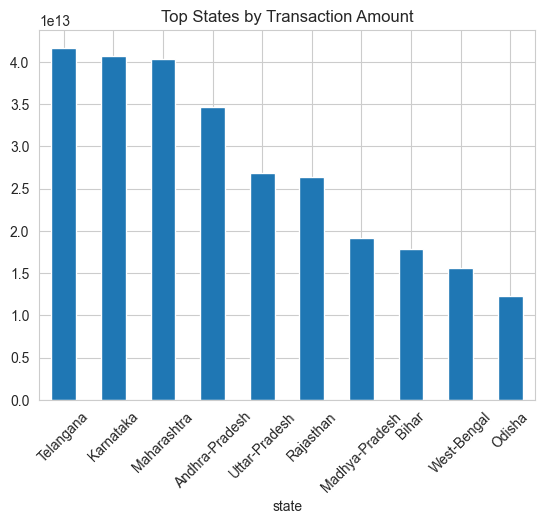

In [20]:
# Chart - 6 visualization code
top_states = df.groupby('state')['transaction_amount'].sum().sort_values(ascending=False).head(10)
plt.figure()
top_states.plot(kind='bar')
plt.title("Top States by Transaction Amount")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart for comparing categories.

##### 2. What is/are the insight(s) found from the chart?

*Few states dominate total transaction value.

*Regional imbalance in adoption.

*Urban states perform better.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Focus expansion in high-growth regions.

*Target underperforming states.

Negative Growth Signals:

*Rural/low-performing states lagging.

*Uneven market penetration.

#### Chart - 7:Transaction Type vs Amount

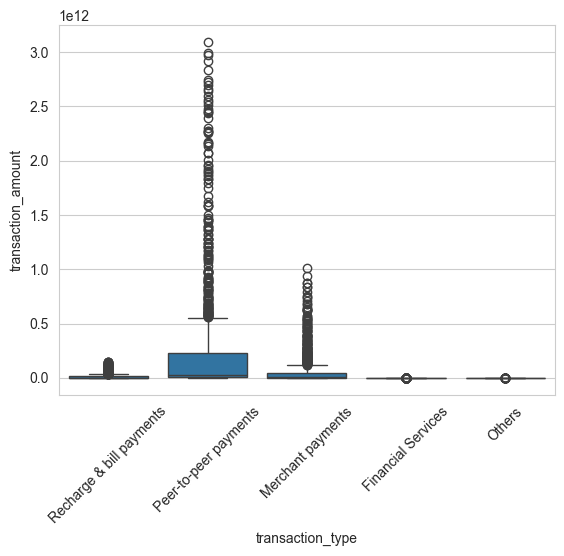

In [21]:
# Chart - 7 visualization code
plt.figure()
sns.boxplot(x='transaction_type', y='transaction_amount', data=df)
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

Boxplot shows spread + outliers.

##### 2. What is/are the insight(s) found from the chart?

*Merchant payments show high variability.

*Some categories have consistent low values.

*Presence of outliers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Identify high-value categories.

*Improve high-revenue services.

Negative Growth Signals:

*Some categories underutilized.

*High variability may indicate instability.

#### Chart - 8:Year vs Transaction Amount

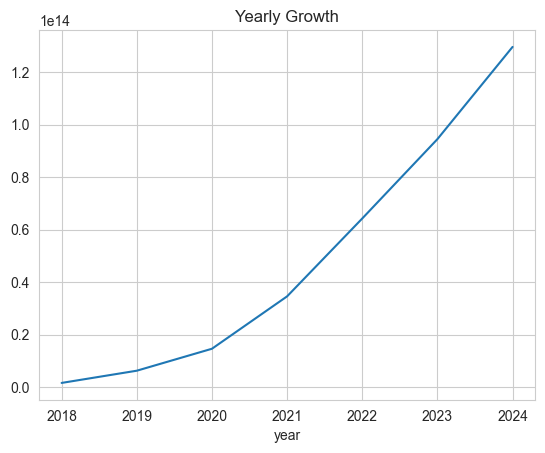

In [22]:
# Chart - 8 visualization code
year_data = df.groupby('year')['transaction_amount'].sum()
plt.figure()
year_data.plot()
plt.title("Yearly Growth")
plt.show()

##### 1. Why did you pick the specific chart?

Line chart shows trends.

##### 2. What is/are the insight(s) found from the chart?

*Strong upward trend.

*Growth accelerates in recent years.

*Increasing transaction value.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Confirms platform scalability.

*Strong market adoption.

Negative Growth Signals:

*Growth heavily dependent on recent years.

*Risk of plateau in future.

#### Chart - 9:Quarter vs Transaction Count

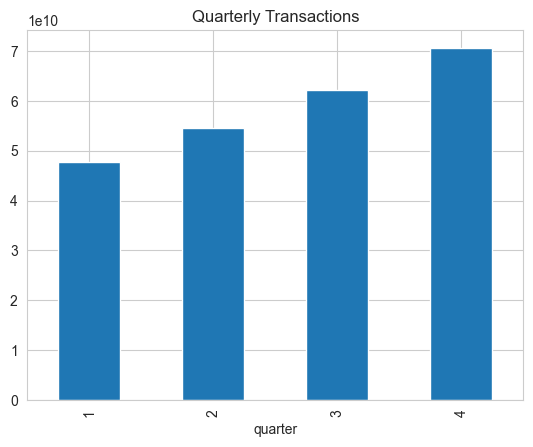

In [23]:
# Chart - 9 visualization code
quarter_data = df.groupby('quarter')['transaction_count'].sum()
plt.figure()
quarter_data.plot(kind='bar')
plt.title("Quarterly Transactions")
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart for comparing categories.

##### 2. What is/are the insight(s) found from the chart?

*Fluctuating transaction volume.

*Certain quarters outperform others.

*Indicates cyclical behavior.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Plan targeted promotions.

*Optimize resource allocation.

Negative Growth Signals:

*Inconsistent user engagement.

*Seasonal dependency risk.

#### Chart - 10:Count vs Amount (Scatter)

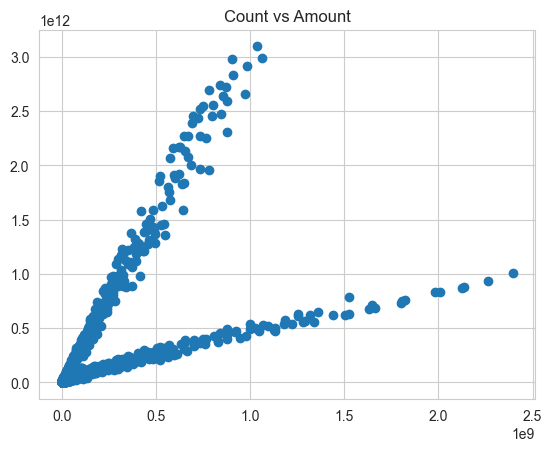

In [24]:
# Chart - 10 visualization code
plt.figure()
plt.scatter(df['transaction_count'], df['transaction_amount'])
plt.title("Count vs Amount")
plt.show()

##### 1. Why did you pick the specific chart?

Scatter shows relationship.

##### 2. What is/are the insight(s) found from the chart?

*Positive relationship between count and amount.

*Higher activity leads to higher revenue.

*Some scattered outliers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Increase user activity → increase revenue.

*Focus on engagement strategies.

Negative Growth Signals:

*Outliers may indicate irregular patterns.

*Not all high counts lead to high value.

#### Chart - 11:State + Year Heatmap

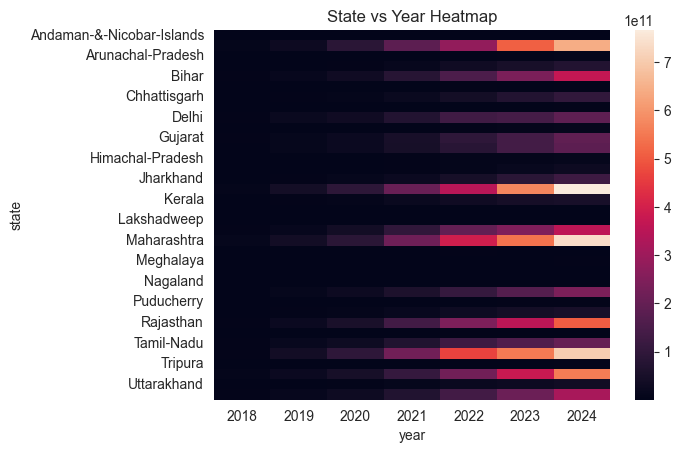

In [25]:
# Chart - 11 visualization code
pivot = df.pivot_table(values='transaction_amount', index='state', columns='year')
plt.figure()
sns.heatmap(pivot)
plt.title("State vs Year Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

Chosen to clearly visualize how transaction intensity varies across states and years in a compact format.

##### 2. What is/are the insight(s) found from the chart?

*Growth varies across states.

*Some states show consistent increase.

*Others remain stagnant.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Identify high-growth regions.

*Region-specific strategies.

Negative Growth Signals:

*Some states show minimal growth.

*Uneven adoption.

#### Chart - 12:Transaction Type + Year

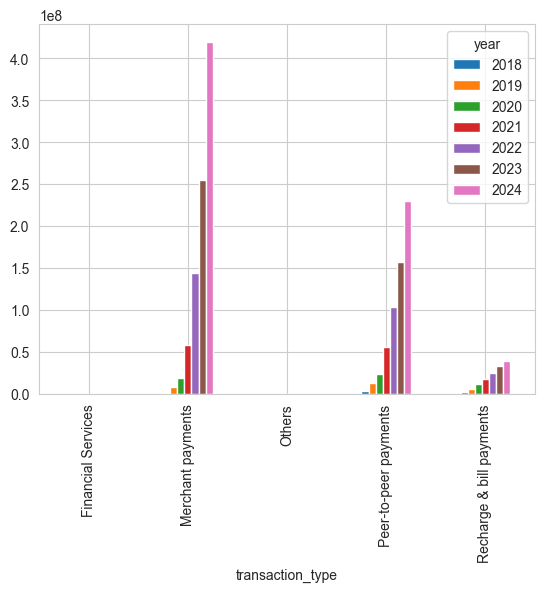

In [26]:
# Chart - 12 visualization code
pivot = df.pivot_table(values='transaction_count', index='transaction_type', columns='year')
pivot.plot(kind='bar')
plt.show()

##### 1. Why did you pick the specific chart?

Chosen to compare growth trends of different transaction categories over time effectively.

##### 2. What is/are the insight(s) found from the chart?

*Some categories grow faster than others.

*Category trends change over time.

*Emerging categories visible.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Invest in fast-growing categories.

*Track evolving user preferences.

Negative Growth Signals:

*Some categories declining.

*Lack of balance in growth.

#### Chart - 13:State + Quarter

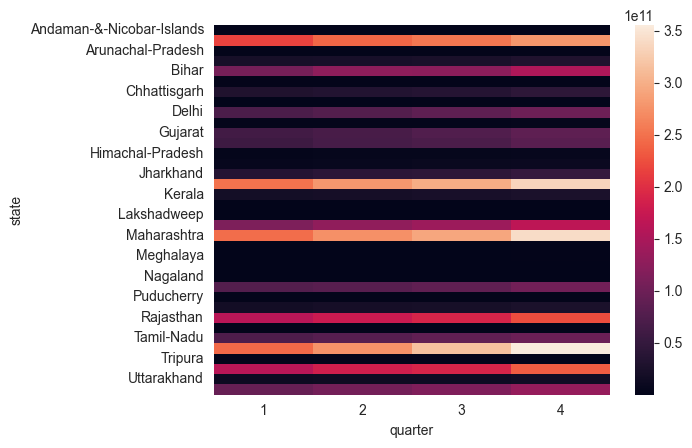

In [27]:
# Chart - 13 visualization code
pivot = df.pivot_table(values='transaction_amount', index='state', columns='quarter')
sns.heatmap(pivot)
plt.show()

##### 1. Why did you pick the specific chart?

Chosen to identify seasonal patterns and regional variations across states and quarters.

##### 2. What is/are the insight(s) found from the chart?

*Seasonal trends differ by state.

*Some states peak in specific quarters.

*Regional behavior differences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:

*Localized campaign planning.

*Region-specific marketing.

Negative Growth Signals:

*Irregular patterns in some states.

*Lack of consistent engagement.

#### Chart - 14 - Correlation Heatmap

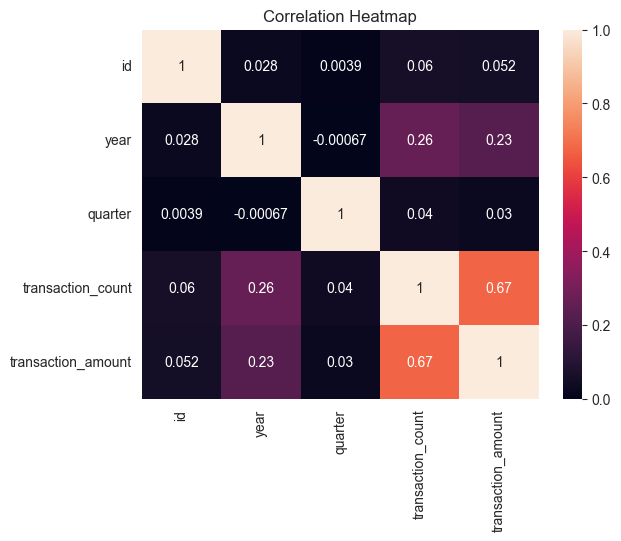

In [28]:
# Correlation Heatmap visualization code
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

Chosen to quickly understand relationships and dependencies between multiple numerical variables.

##### 2. What is/are the insight(s) found from the chart?

*Strong correlation between count & amount.

*Weak correlation with quarter.

*Moderate relation with year.

#### Chart - 15 - Pair Plot

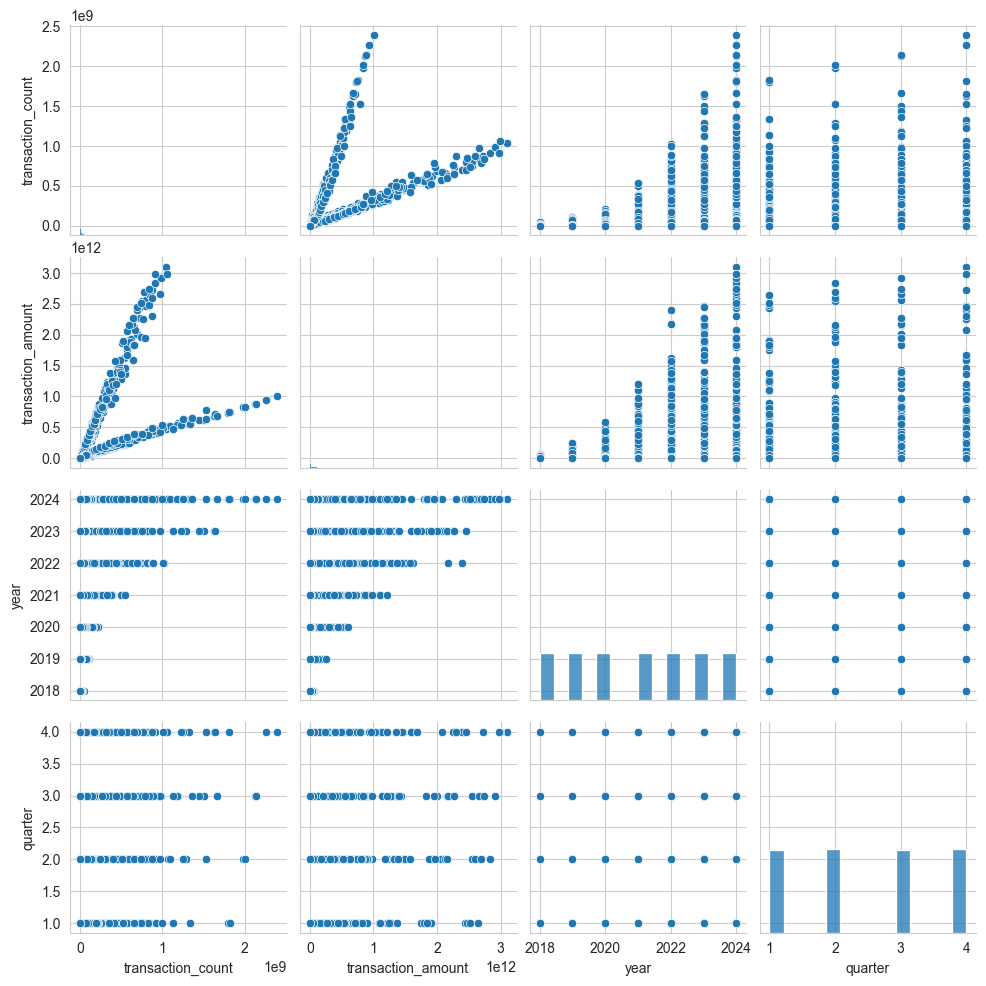

In [29]:
# Pair Plot visualization code
sns.pairplot(df[['transaction_count','transaction_amount','year','quarter']])
plt.show()

##### 1. Why did you pick the specific chart?

Chosen to explore distributions and relationships between multiple variables simultaneously in one view.

##### 2. What is/are the insight(s) found from the chart?

*Clear relationships between variables.

*Clusters of similar behavior.

*Outliers visible.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

*There is a significant difference in transaction amounts across different states.

*Transaction amount has significantly increased over the years.

*Different transaction types have significantly different transaction amounts.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H₀ (Null): There is no significant difference in transaction amount across states

H₁ (Alternate): There is a significant difference in transaction amount across states

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value
# (ANOVA Test)
from scipy.stats import f_oneway

groups = [group['transaction_amount'].values for name, group in df.groupby('state')]

stat, p = f_oneway(*groups)

print("P-value:", p)

P-value: 1.6050967644129323e-109


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA

##### Why did you choose the specific statistical test?

Used to compare means of more than 2 groups (multiple states)

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H₀: Transaction amount does not differ across years

H₁: Transaction amount differs significantly across years

#### 2. Perform an appropriate statistical test.

In [31]:
# Perform Statistical Test to obtain P-Value
# (ANOVA Test)
groups = [group['transaction_amount'].values for name, group in df.groupby('year')]

stat, p = f_oneway(*groups)

print("P-value:", p)

P-value: 6.373686853235128e-58


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA

##### Why did you choose the specific statistical test?

Comparing transaction amounts across multiple years

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H₀: Transaction amount is same across all transaction types

H₁: Transaction amount differs across transaction types

#### 2. Perform an appropriate statistical test.

In [32]:
# Perform Statistical Test to obtain P-Value
# (ANOVA Test)

groups = [group['transaction_amount'].values for name, group in df.groupby('transaction_type')]

stat, p = f_oneway(*groups)

print("P-value:", p)

P-value: 3.7407202094168395e-164


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA

##### Why did you choose the specific statistical test?

Comparing multiple categories (transaction types)

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data

### 6. Data Scaling

In [ ]:
# Scaling your data

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***